# Pair comparison (uncoupled vs concerted)
as a function of the timescale of conformational dynamics

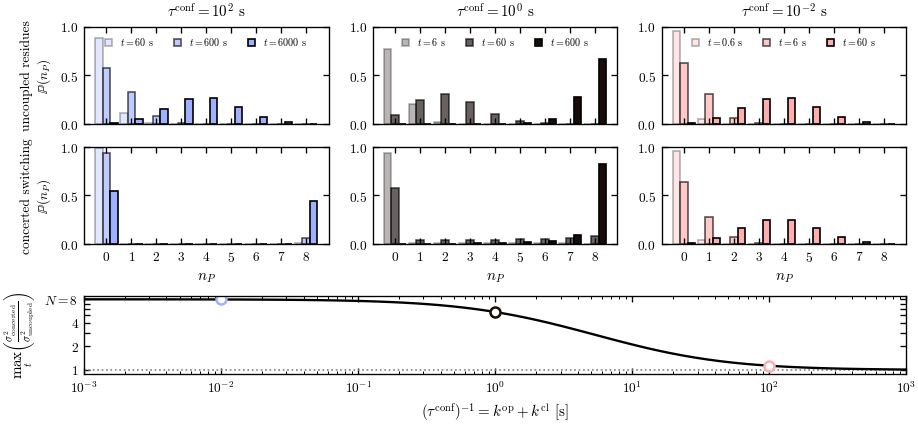

In [1]:
# ------------------------------------------------------------------
# concerted switching vs uncoupled residues:
#   scan k_op, k_cl for a fixed N and k_int, show how the uptake
#   envelope shape and the peak variance ratio depend on the switch
#   timescale.  Copy into a notebook cell; tweak the parameters at
#   the top.
# ------------------------------------------------------------------
import os, sys
import numpy as np
import matplotlib.pyplot as plt

_here = os.getcwd()
_py = os.path.abspath(os.path.join(_here, '..', 'python'))
if _py not in sys.path:
    sys.path.insert(0, _py)

import hdx_env as H
from hdx_env import (
    UncoupledResidues, ConcertedSwitching, FullMarkov,
    averagine_composition, natural_envelope, mass_envelope,
    COLORS, LABELS,
)
H.set_plot_style(use_tex=False)

PLOTS_DIR = os.path.abspath(os.path.join(_here, '..', 'figures'))
os.makedirs(PLOTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Fixed peptide: k_int = 1 for every residue
# ---------------------------------------------------------------------------
N       = 8
P       = tuple(range(N))
k_int   = np.ones(N)
kk      = np.arange(N + 1)
t       = np.logspace(-4, 6, 401)
t_snaps = np.array([10, 100, 1000])

# ---------------------------------------------------------------------------
# Parameters: r1 = k_op/k_cl  fixed,  τ_conf = k_op + k_cl  scanned
# ---------------------------------------------------------------------------
r1         = 1.0 / 99.0                           # k_cl/k_op = 99
tau_values = np.array([1e-4, 1e-2, 1.0]) * (1.0 + 1.0/r1)
tau_scan   = np.logspace(np.log10(tau_values.min()) - 1.5,
                         np.log10(tau_values.max()) + 1.5, 80)

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def _centre_var(ud):
    m1 = (ud * kk).sum(axis=1)
    return m1, (ud * kk**2).sum(axis=1) - m1**2

def build_regimes(r1, tau):
    k_op = tau * r1 / (1.0 + r1)
    k_cl = tau       / (1.0 + r1)
    ind  = H.UncoupledResidues(np.full(N, k_op), np.full(N, k_cl), k_int)
    conc = H.ConcertedSwitching(k_op, k_cl, k_int)
    return ind, conc, k_op, k_cl

# ---------------------------------------------------------------------------
# Figure layout: 3 rows × len(tau_values) cols  (envelopes + peak-ratio)
# ---------------------------------------------------------------------------
nc  = len(tau_values)
fig = plt.figure(figsize=(2.4 * nc + 0.5, 3.6), constrained_layout=True)
gs  = fig.add_gridspec(3, nc,
                       height_ratios=[1.0, 1.0, 0.8])

ax_env = [[fig.add_subplot(gs[0, j]) for j in range(nc)],
          [fig.add_subplot(gs[1, j]) for j in range(nc)]]
for ax in ax_env[0]:
    plt.setp(ax.get_xticklabels(), visible=False)
ax_peak = fig.add_subplot(gs[2, :])      # peak-ratio sweep underneath

# ---------------------------------------------------------------------------
# Loop over showcase τ values: envelopes + peak-ratio markers
# ---------------------------------------------------------------------------


cmap = plt.get_cmap('berlin')
tau_colors  = [cmap(ti / max(nc - 1, 1)) for ti in range(nc)]
peak_ratios = []
for ti, tau in enumerate(tau_values):
    color       = tau_colors[ti]
    ind, conc, k_op, k_cl = build_regimes(r1, tau)

    # variance trajectories (used only for the peak ratio marker)
    _, v_i = _centre_var(ind .uptake_distribution(P, t))
    _, v_c = _centre_var(conc.uptake_distribution(P, t))

    # peak ratio marker
    mask = v_i > 1e-3 * v_i.max()
    peak_ratios.append(
        np.nanmax(np.where(mask, v_c / np.maximum(v_i, 1e-15), np.nan)))

    # envelopes at snapshot times
    ud_i_snap = ind .uptake_distribution(P, t_snaps/np.sqrt(tau)*6/10)
    ud_c_snap = conc.uptake_distribution(P, t_snaps/np.sqrt(tau)*6/10)
    width     = 0.9 / len(t_snaps)
    for si, tsnap in enumerate(t_snaps):
        off   = (si - (len(t_snaps) - 1) / 2) * width
        alpha = 0.3 + 0.7 * si / max(len(t_snaps) - 1, 1)
        ax_env[0][ti].bar(kk + off , ud_i_snap[si], width=width,
                          color=color, alpha=alpha,
                          label=rf'$t={tsnap/np.sqrt(tau)*6/10:g}$ s',
                          edgecolor='k', linewidth=1)
        ax_env[1][ti].bar(kk + off, ud_c_snap[si], width=width,
                          color=color, alpha=alpha,
                          label=rf'$t={tsnap/np.sqrt(tau)*6/10:g}$ s',
                          edgecolor='k', linewidth=1)
    for row in range(2):
        ax_env[row][ti].set_xticks(kk)
        ax_env[row][ti].set_ylim(0, 1.0)
        if ti == 0:
            ax_env[row][ti].set_ylabel(
                ['uncoupled residues', 'concerted switching'][row] + '\n' + r'$\mathbb{P}(n_P)$', fontsize=8)

    ax_env[1][ti].set_xlabel(r'$n_P$')
    exponent = int(round(np.log10(tau)))
    ax_env[0][ti].set_title(rf'$\tau^{{\rm conf}}= 10^{{{-exponent}}}$ s', fontsize=9)

peak_ratios = np.array(peak_ratios)

ax_env[0][0].legend(loc='upper center', fontsize=6, ncol=tsnap, handlelength=0.7, frameon=False)
ax_env[0][1].legend(loc='upper center', fontsize=6, ncol=tsnap, handlelength=0.7, frameon=False)
ax_env[0][2].legend(loc='upper center', fontsize=6, ncol=tsnap, handlelength=0.7, frameon=False)


# ---------------------------------------------------------------------------
# Peak-ratio sweep at finer resolution
# ---------------------------------------------------------------------------
R_scan = []
for tau in tau_scan:
    ind, conc, *_ = build_regimes(r1, tau)
    _, v_i = _centre_var(ind .uptake_distribution(P, t))
    _, v_c = _centre_var(conc.uptake_distribution(P, t))
    mask   = v_i > 1e-3 * v_i.max()
    ratio  = np.where(mask, v_c / np.maximum(v_i, 1e-15), np.nan)
    R_scan.append(np.nanmax(ratio))
R_scan = np.array(R_scan)

ax_peak.axhline(1.0, color='grey', ls=':', lw=1.0)
ax_peak.loglog(tau_scan, R_scan, '-', color='k', lw=1.4)
ax_peak.set_xlim(10**-3,10**3)
for tau_i, pr_i, col in zip(tau_values, peak_ratios, tau_colors):
    ax_peak.loglog(tau_i, pr_i, 'o', color=col,
                   ms=6, mfc='white', mew=1.5)
ax_peak.set_xlabel(r'$(\tau^{\rm conf})^{-1}=k^{\rm op}+k^{\rm cl}$ [s]', fontsize=9)
ax_peak.set_ylabel(r'$\max_t \left(\frac{\sigma^2_{\rm concerted}}{\sigma^2_{\rm uncoupled}} \right)$', fontsize=9)
ax_peak.set_yticks([1,2,3,4,5,6,7,8], labels=[1,2,'',4,'','','',r'$N=8$'])
#ax_peak.set_title(rf'$r_1=k_{{\rm op}}/k_{{\rm cl}}={r1:g}$, $N={N}$', fontsize=9)

fig.savefig(os.path.join(PLOTS_DIR, 'fig_concerted_variance_tconf.pdf'))
plt.show()